In [1]:
import numpy as np
import math
from numba import jit
import time
from datetime import datetime
import os
import sys
from normalization import normalize
import scipy.io
# from functions import EZs, x0_w_init
from Dynamics import Dynamics
from file_loading import *
from matplotlib import pyplot as plt

In [2]:
# Loading the patient specific network 
patient_name='P1'
EZ_ind=61-1
EZ=np.array([EZ_ind])
noise_strength=0.05

connectivity_file="connectivity_"+patient_name+".zip"
network_directory="../data/"

#loading the weights matrix
W=get_data(network_directory+connectivity_file,'weights.txt')
#normalizing the weights matrix 
W_normal=normalize(W,"global")
N=W_normal.shape[0]

# Simulation time bin
h=0.05
# Speed of interactions in units of epileptor dynamics equivalent to 3000mm/sec
speed=60.0  
Tau_normal=get_data(network_directory+connectivity_file,'tract_lengths.txt')/speed
Tau=(Tau_normal/h).astype(int)
t0=np.max(Tau)


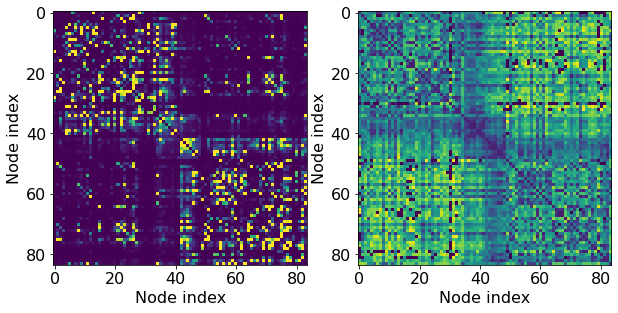

In [5]:
# visualizing the weights and delays matrices
plt.rcParams['font.size'] = '16'
plt.figure(figsize=(10,5))
ax11=plt.subplot(1,2,1)
ax11.imshow(W_normal)
ax11.set_xlabel('Node index')
ax11.set_ylabel('Node index')
ax12=plt.subplot(1,2,2)
ax12.imshow(Tau_normal)
ax12.set_xlabel('Node index')
ax12.set_ylabel('Node index')
plt.show()

In [6]:
# Setting up the simulation

# total simulation time in units of epileptor. Divide by 50 to get time in seconds
simulation_time=36000.0
# time that the EZ node becomes active (EZ_x0 --> -1.6)
t_EZ_onset=1000.0
EZ_x0=-1.6
# total number of time bins in the simulation
M=t0+int(simulation_time/h)
# the timebin at which the simulation starts
M0=t0+int(t_EZ_onset/h)
# setting the random seed
seed=int(1000*time.time())
seed =np.mod(seed,2**31)+1

# Global connectivity 
w= 1.5
# Surround excitability
x0=-2.15


# the network
Network={
    "h":h,
    "Tau":Tau,
    "W":W_normal * w,
    "N":N,
    "t0":t0,
    "M":M,
    "EZs":EZ
}

# epileptor parameters
epileptor_6D={
    "model_name":"epileptor",
    "model_dimension":6,
    "I1" : 3.1,  
    "I2" : 0.45,  
    "r" : 0.00015,  
    "tau2" : 10.0,   
    "gamma" : 0.01,
    "m":0.00,
    "x0":np.ones(N)*x0
}


In [7]:
# creating a simulation object from the Dynamics class
Y=Dynamics(epileptor_6D,"Runge_Kutta_2",Network)
# setting the initial conditions for the 6 variabls of the dynamics 
# Y.Set_Initial_Condition([ x1 , y1 , z , x2 , y2 , g ])
Y.Set_Initial_Condition([ -1.6 , -12.0 , 3.2 , 0.00 , 0.00 , -160 ])
# set the noise (Same convention as initial conditions)
Y.Set_noise([ 0.0 , 0.0 , 0.0 , noise_strength  , noise_strength  , 0.0 ] , seed)
# forcing refractory state after seizure termination
Y.refractory=True
# running the simulation

Y.run(t_EZ_onset,EZ_x0) 

seizure size = 84.0


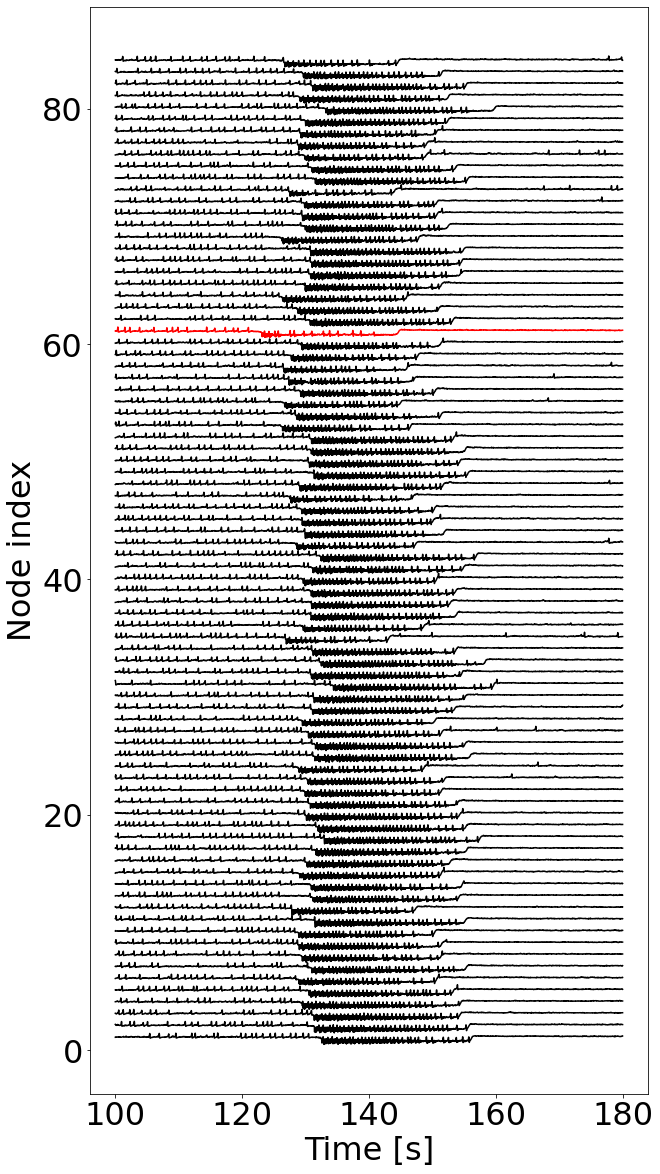

In [20]:
plt.figure(figsize=(10,20))
t1=5000
t2=9000
for i in range(N):
    if(i==EZ_ind):
        plt.plot(Y.T_axis[t1:t2]/50,0.2*Y.Y[t1:t2,i]+i+1,'-r')
    else:
        plt.plot(Y.T_axis[t1:t2]/50,0.2*Y.Y[t1:t2,i]+i+1,'-k')

plt.xlabel('Time [s]')  
plt.ylabel('Node index')
plt.rcParams['font.size'] = '32'
print('seizure size =',np.sum(Y.seizure_01/2))